Shape: (1500, 6)


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


Columns:
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ticket_id         1500 non-null   object
 1   channel           1500 non-null   object
 2   customer_message  1500 non-null   object
 3   sentiment_label   1500 non-null   object
 4   word_count        1500 non-null   int64 
 5   urgent_flag       1500 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 70.4+ KB


None

Class distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64
Average text length: 72.75666666666666
Average word count: 12.722666666666667


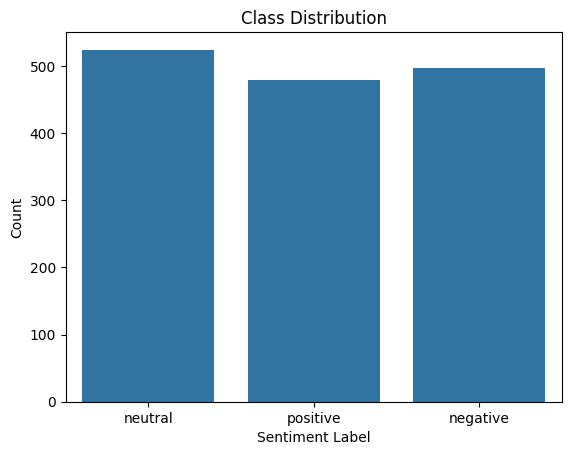

In [1]:
# Task 1: Dataset Understanding
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/ai_project_synthetic_datasets/part_3_nlp_sequence_modeling/customer_support_text_classification.csv")

print("Shape:", df.shape)
display(df.head())

print("Columns:")
print(df.columns)

print("Info:")
display(df.info())

print("Class distribution:")
print(df["sentiment_label"].value_counts())

df["text_length"] = df["customer_message"].astype(str).apply(len)
df["word_count"] = df["customer_message"].astype(str).apply(lambda x: len(x.split()))

print("Average text length:", df["text_length"].mean())
print("Average word count:", df["word_count"].mean())

sns.countplot(data=df, x="sentiment_label")
plt.title("Class Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.show()

In [2]:
# Task 2: Text Preprocessing
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["customer_message"].apply(clean_text)

display(df[["customer_message", "clean_text"]].head())

,customer_message,clean_text
0,I need information about the payment process. ...,i need information about the payment process m...
1,I need information about the payment process.,i need information about the payment process
2,The refund process was fast and convenient. I ...,the refund process was fast and convenient i a...
3,My refund is still pending and this experience...,my refund is still pending and this experience...
4,Please tell me how to update my account details.,please tell me how to update my account details


In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 5000
max_len = 30

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])

sequences = tokenizer.texts_to_sequences(df["clean_text"])
padded_sequences = pad_sequences(
    sequences,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

print("Example sequence:", sequences[0])
print("Padded sequence shape:", padded_sequences.shape)

Example sequence: [5, 30, 137, 40, 2, 91, 34, 4, 7, 8, 3, 11, 13, 9, 14, 9, 15]
Padded sequence shape: (1500, 30)


In [4]:
# Task 3: Text Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df["clean_text"])

print("TF-IDF shape:", X_tfidf.shape)

feature_names = tfidf.get_feature_names_out()
print("Sample TF-IDF features:")
print(feature_names[:20])
print("Tokenizer sequence shape:", padded_sequences.shape)

print("Sample tokenizer sequence:")
print(padded_sequences[0])

TF-IDF shape: (1500, 180)
Sample TF-IDF features:
['about' 'account' 'activate' 'after' 'ago' 'am' 'analytics' 'and' 'any'
 'app' 'appreciate' 'arrived' 'as' 'assigned' 'available' 'bad' 'because'
 'been' 'between' 'billing']
Tokenizer sequence shape: (1500, 30)
Sample tokenizer sequence:
[  5  30 137  40   2  91  34   4   7   8   3  11  13   9  14   9  15   0
   0   0   0   0   0   0   0   0   0   0   0   0]


Baseline Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Confusion Matrix:
[[ 99   0   0]
 [  0 105   0]
 [  0   0  96]]


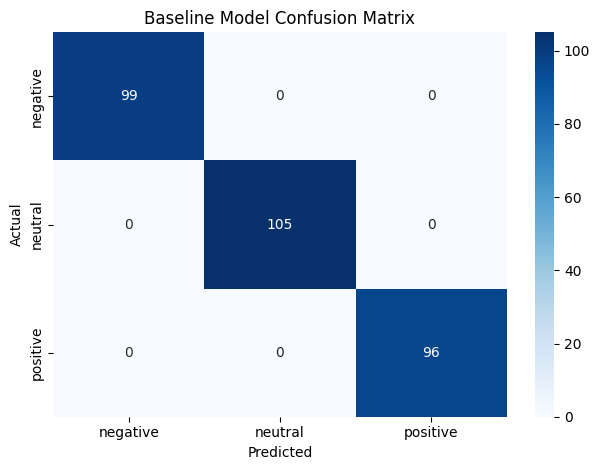

In [12]:
# Task 4: Baseline Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

X = X_tfidf
y = df["sentiment_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Baseline Accuracy:", accuracy)

print("Classification Report:")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=baseline_model.classes_)
print("Confusion Matrix:")
print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=baseline_model.classes_,
    yticklabels=baseline_model.classes_
)

plt.title("Baseline Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("results/model_evaluation.png", bbox_inches="tight")
plt.show()

In [11]:
# Task 5: Sequence Model using LSTM
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df["sentiment_label"])
y_categorical = to_categorical(y_encoded)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    padded_sequences,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [10]:
history_lstm = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)
lstm_model.summary()

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 7.4646e-04
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 5.5126e-04
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 4.3118e-04
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 1.0000 - loss: 8.7532e-04 - val_accuracy: 1.0000 - val_loss: 3.4599e-04
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 1.0000 - loss: 7.4331e-04 - val_accuracy: 1.0000 - val_loss: 2.8424e-04
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 1.0000 - loss: 6.3022e-04 - val_accuracy: 1.0000 - val_loss: 2.3708e-04
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 1.0000 - los

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, 30, 64)           │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (32, 64)               │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 32)               │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,065,611 (4.06 MB)

 Trainable params: 355,203 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 710,408 (2.71 MB)

In [9]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_seq, y_test_seq, verbose=0)

print("LSTM Testing Loss:", lstm_loss)
print("LSTM Testing Accuracy:", lstm_accuracy)

LSTM Testing Loss: 0.001758045400492847
LSTM Testing Accuracy: 1.0


In [13]:
sample_df = df.loc[y_test.index, ["customer_message", "sentiment_label"]].copy()
sample_df["predicted_label"] = y_pred
sample_df = sample_df.head(10)

with open("results/sample_predictions.txt", "w") as f:
    for _, row in sample_df.iterrows():
        f.write(f"Text: {row['customer_message']}\n")
        f.write(f"Actual: {row['sentiment_label']}\n")
        f.write(f"Predicted: {row['predicted_label']}\n")
        f.write("-" * 50 + "\n")